In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import warnings
import pickle as pkl
import sccoda

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import tensorflow as tf
tf.random.set_seed(1)  # setting the same seed makes multiple runs of scCODA exactly reproducible

warnings.filterwarnings("ignore")

basedir = "/mnt/storage1/Anand_temp/github_repos/HTAPP_neuroblastoma/output/Fig2/"

#resolution = "fine"  # use fine or coarse resolution to define cell types
resolution = "coarse"
countsfile = f"{basedir}cell_counts.csv"
#"cleaned" file has erythrocytes and zona glomerulosa cell counts removed

model_specs = [("MYCN", "C(MYCN, Treatment('non-amplified'))")]

2025-01-17 11:49:22.716117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737136162.735492 2571367 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737136162.741624 2571367 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-17 11:49:22.762756: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Read counts file into scCODA
cell_counts = pd.read_csv(countsfile, skip_blank_lines = True)
#sampletracking.dropna(axis=0, how='all', inplace = True)
cell_counts = cell_counts.drop(columns=['Unnamed: 0'])

first_covariate_index = cell_counts.columns.tolist().index('orig.ident')
cell_counts.columns[first_covariate_index:]

# Subset counts data to only look at nucleus samples
# cell_counts = cell_counts[cell_counts['condition'] == "nucleus"]
cell_counts.head()

data_nb = dat.from_pandas(cell_counts, covariate_columns=cell_counts.columns[first_covariate_index:])
print(data_nb.X)
print(data_nb.obs)

#remove "unknown" methylation groups
#data_nb = data_nb[data_nb.obs["Methylation_Group"].isin(["1", "2","3", "4"])]
#print(data_nb.obs)

[[  850  2743  1666   959]
 [  328   616  6930   287]
 [  655  2159  3918   818]
 [  320   683  7578   198]
 [ 1858   852  2706  2788]
 [  112   343  6414   233]
 [ 5992   655  1138  8901]
 [  167  1698  5172   212]
 [    0    88  7339    18]
 [ 1038  4011  6991  1921]
 [  338   168  7320   582]
 [    0    90  6008   183]
 [  428  1542  9358  1123]
 [ 1345  1170  2949  4860]
 [  262   637  6950   117]
 [  480     0  6516     0]
 [ 1671  1190   281   567]
 [   75   197  2508     0]
 [  673  8651 13434   417]
 [  525   617  7531   293]
 [  325   210  6804  1054]
 [  117   524  4904   122]
 [    0     0  5595   114]
 [  316  1369  5340   287]
 [  270  1502  4886   324]
 [  150   766 11224   518]
 [  597   635  3098   675]
 [  244  1116 25555   662]
 [    0    78  4995     0]
 [  203   817  1999   533]
 [ 1018   376  3447  4855]
 [ 1931  3159  5697  6455]
 [    0   895 10916  2714]
 [ 2243   227   942  3448]
 [  106  1253  4318   314]
 [  649  2467 13570   534]
 [  303   878 25173   133]
 

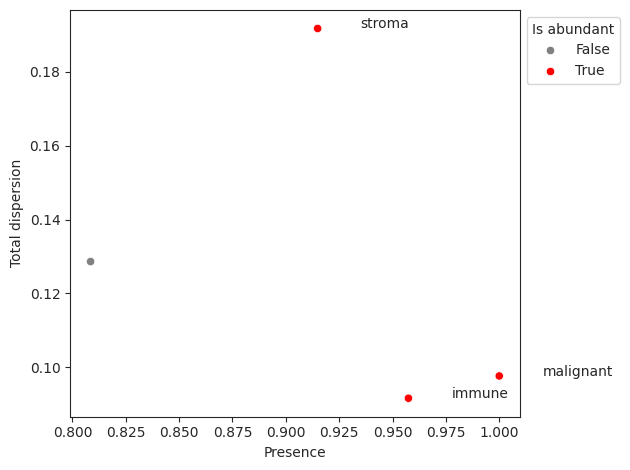

In [3]:
viz.rel_abundance_dispersion_plot(
    data=data_nb,
    abundant_threshold=0.9
)
plt.show()

feature: MYCN
formula: C(MYCN, Treatment('non-amplified'))
Reference: endothelium


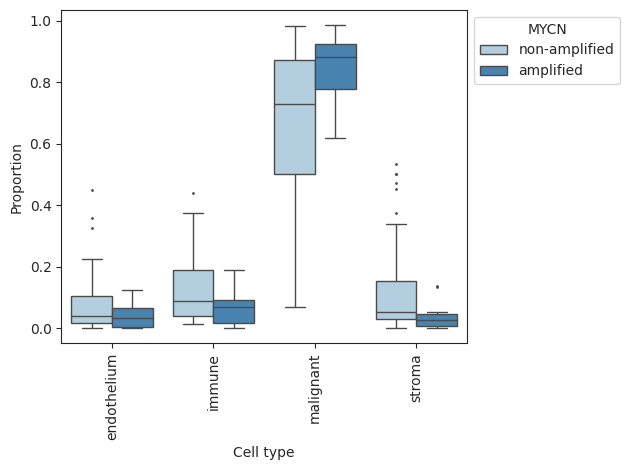

InternalError: cudaGetDevice() failed. Status: CUDA driver version is insufficient for CUDA runtime version

In [4]:
tf.random.set_seed(1)

i = 0
feature = model_specs[i][0]
formula = model_specs[i][1]

cell_types = data_nb.var.index
results_cycle = pd.DataFrame(index=cell_types, columns=["times_credible"]).fillna(0)

for feature, formula in model_specs:
    for ct in cell_types:
        print(f"feature: {feature}")
        print(f"formula: {formula}")
        print(f"Reference: {ct}")

        viz.boxplots(data_nb, feature_name=feature, plot_facets=False, y_scale="relative", add_dots=False)
        plt.savefig(f"{basedir}/{feature}.pdf", bbox_inches="tight")
        plt.show()
        
        # Run inference
        model_temp = mod.CompositionalAnalysis(data_nb, formula=model_specs[i][1], reference_cell_type=ct)
        temp_results = model_temp.sample_hmc()
        temp_results.summary()
        print(temp_results.credible_effects())
                     
        # Select credible effects
        cred_eff = temp_results.credible_effects()
        cred_eff.index = cred_eff.index.droplevel(level=0)
        
        # add up credible effects'
        results_cycle["times_credible"] += cred_eff.astype("int")
        
    results_cycle["pct_credible"] = results_cycle["times_credible"]/len(cell_types)
    results_cycle["is_credible"] = results_cycle["pct_credible"] > 0.5
    print(results_cycle)